<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/perceptron_binary_classification_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PERCEPTRON CLASSIFIER DEMO
# Production-Level Workflow
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# ============================================================
# SYNTHETIC DATASET
# ============================================================

X, y = make_classification(
    n_samples=1000,

    n_features=2,

    n_redundant=0,

    n_informative=2,

    n_clusters_per_class=1,

    random_state=42
)

print("Dataset Shape:", X.shape)

Dataset Shape: (1000, 2)


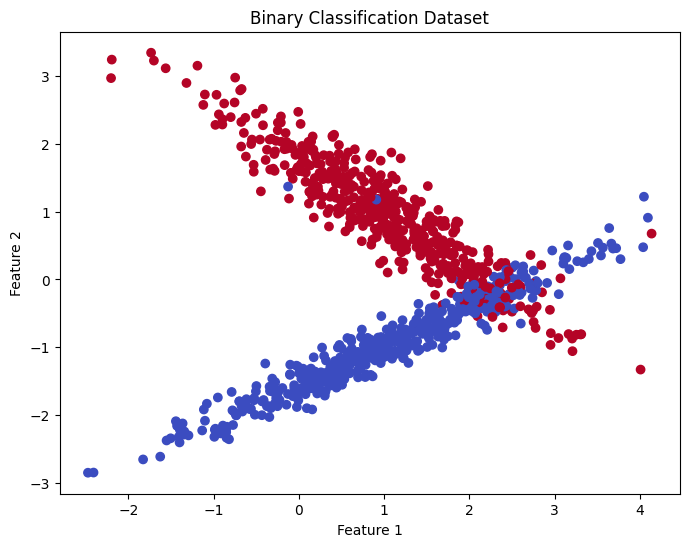

In [ ]:
# ============================================================
# VISUALIZE DATASET
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm'
)

plt.title("Binary Classification Dataset")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [ ]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
# ============================================================
# CREATE MODEL
# ============================================================

model = Perceptron(
    max_iter=1000,

    eta0=0.01,

    random_state=42
)

model.fit(X_train, y_train)

Perceptron(eta0=0.01, random_state=42)

In [ ]:
# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [1 0 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1
 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0
 1 1 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 1 0
 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 0
 1 1 0 0 0 1 0 0 1 0 1 0 0 1 1]


In [ ]:
# ============================================================
# MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9050

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       104
           1       0.99      0.81      0.89        96

    accuracy                           0.91       200
   macro avg       0.92      0.90      0.90       200
weighted avg       0.92      0.91      0.90       200



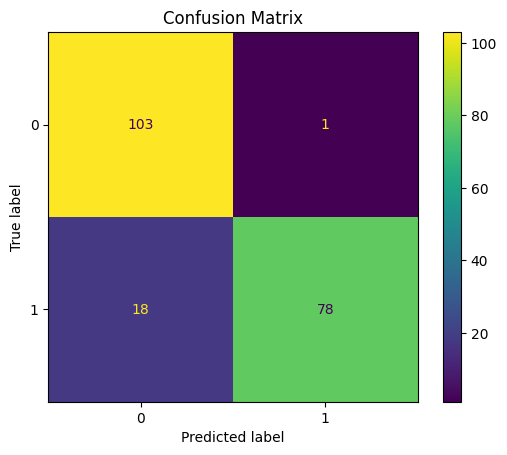

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

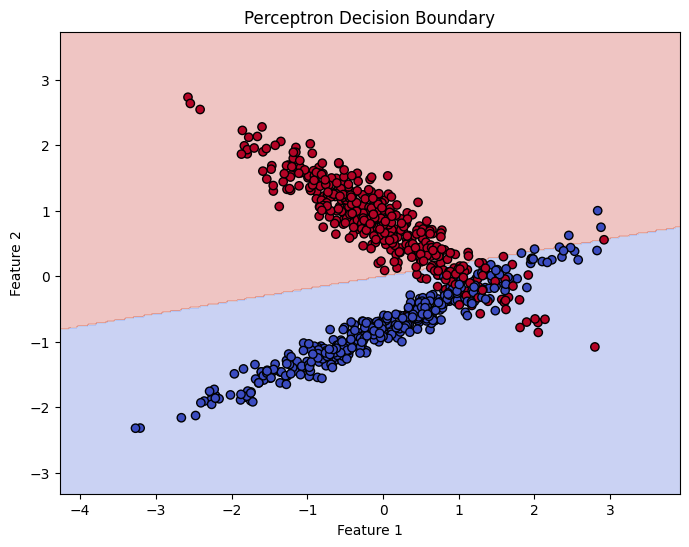

In [ ]:
# ============================================================
# DECISION BOUNDARY
# ============================================================

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1

y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap='coolwarm'
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor='k',
    cmap='coolwarm'
)

plt.title("Perceptron Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()